### RaschPy thresholds MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the thresholds parameterisation, each rater has a separate severity for every threshold (shared across items), rather than a single scalar severity as in the global model.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Thresholds(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:476: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_96666/3952269013.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Thresholds(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=999)
sim.responses.to_csv('mfrm_thresholds_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_thresholds_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     3.0     3.0     3.0     1.0     3.0     3.0     3.0   
        Person_2     2.0     4.0     3.0     3.0     1.0     1.0     3.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     3.0     4.0      3.0      4.0      3.0  
        Person_2     3.0     3.0      2.0      3.0      1.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the thresholds parameterisation (a separate severity per rater x threshold combination, shared across items). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_thresholds()

CPU times: user 2.98 ms, sys: 332 μs, total: 3.32 ms
Wall time: 3.1 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1    1.087638
Item_2    0.170057
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


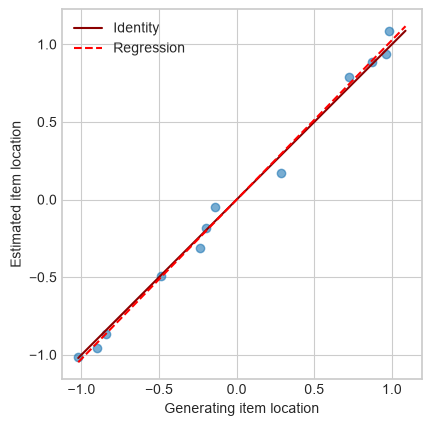

item location Pearson correlation:              0.997
item location SD ratio (estimated / generating): 1.03
item location regression coefficient:            1.027
item location RMSE:                              0.063


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_thresholds_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_thresholds(full=True)
mfrm.item_stats_thresholds.to_csv('mfrm_thresholds_item_stats.csv')

CPU times: user 3.17 s, sys: 119 ms, total: 3.29 s
Wall time: 3.29 s


Check the item statistics table

In [14]:
mfrm.item_stats_thresholds

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,1.088,0.048,0.991,1.179,1600,0.428,0.922,-2.249,0.933,-1.941,0.711,0.695
Item_2,0.170,0.043,0.083,0.247,1600,0.507,1.032,0.912,0.998,-0.042,0.691,0.678
Item_3,-0.492,0.039,-0.574,-0.420,1600,0.570,1.044,1.247,1.032,0.911,0.653,0.659
Item_4,0.788,0.045,0.705,0.880,1600,0.450,1.031,0.870,1.018,0.518,0.687,0.692
Item_5,0.935,0.046,0.851,1.019,1600,0.439,1.038,1.077,1.044,1.247,0.697,0.694
Item_6,-0.048,0.037,-0.124,0.023,1600,0.534,0.962,-1.086,0.951,-1.408,0.670,0.672
Item_7,-0.181,0.044,-0.274,-0.099,1600,0.543,0.995,-0.143,0.996,-0.088,0.672,0.668
Item_8,-1.014,0.047,-1.111,-0.932,1600,0.615,1.049,1.384,1.039,1.110,0.627,0.645
Item_9,-0.864,0.048,-0.961,-0.767,1600,0.598,0.992,-0.221,0.965,-0.990,0.628,0.649
Item_10,-0.312,0.044,-0.398,-0.231,1600,0.551,0.984,-0.447,0.975,-0.707,0.653,0.664


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_thresholds(full=True)
mfrm.threshold_stats_thresholds.to_csv('mfrm_thresholds_threshold_stats.csv')

CPU times: user 102 ms, sys: 3.38 ms, total: 105 ms
Wall time: 105 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_thresholds

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-4.462,0.061,-4.515,-4.284,1.003,0.099,1.043,0.520,0.997,0.356,0.367
Threshold 2,-1.599,0.038,-1.671,-1.521,0.991,-0.758,0.992,-0.331,1.019,0.763,0.730
Threshold 3,-1.086,0.034,-1.147,-1.018,0.985,-1.420,0.982,-0.825,1.026,0.893,0.920
Threshold 4,2.437,0.038,2.352,2.498,0.985,-1.132,0.986,-0.421,1.017,0.760,0.770
Threshold 5,4.710,0.067,4.530,4.791,1.088,1.483,1.109,0.886,0.951,0.200,0.215


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

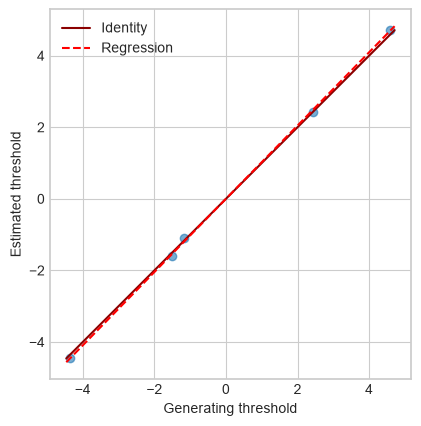

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 1.024
threshold regression coefficient:            1.023
threshold RMSE:                              0.093


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_thresholds_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [18]:
%%time
mfrm.rater_stats_df_thresholds()
mfrm.rater_stats_thresholds.to_csv('mfrm_thresholds_rater_stats.csv')

CPU times: user 43.7 ms, sys: 2.06 ms, total: 45.8 ms
Wall time: 46 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_thresholds

Threshold 1        Threshold 2        Threshold 3        Threshold 4  \
           Estimate     SE    Estimate     SE    Estimate     SE    Estimate   
Rater_1       0.610  0.130       0.052  0.084      -0.170  0.065       0.232   
Rater_2      -0.382  0.196      -0.170  0.089      -0.227  0.068      -0.317   
Rater_3       0.233  0.167      -0.364  0.073       1.100  0.058      -0.389   
Rater_4      -0.831  0.277      -0.371  0.084       0.422  0.056       0.697   
Rater_5       0.183  0.188      -0.196  0.094      -0.594  0.061       0.335   
Rater_6       0.038  0.191       0.123  0.079      -0.238  0.061      -1.083   
Rater_7       0.499  0.177       0.060  0.088       0.002  0.061       0.884   
Rater_8      -0.349  0.157       0.865  0.094      -0.295  0.076      -0.360   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.066      -0.230  0.264             2400.0    0.986     0.980  
Rater_2  0.063      -0.011  0.254             2400.0    0.994     0.994  
Rater_3  0.076      -0.651  0.160             2400.0    1.038     1.035  
Rater_4  0.085      -0.259  0.261             2400.0    0.978     0.969  
Rater_5  0.065       0.203  0.197             2400.0    1.076     1.069  
Rater_6  0.061       0.393  0.241             2400.0    0.998     0.985  
Rater_7  0.090       0.435  0.333             2400.0    0.933     0.910  
Rater_8  0.058       0.120  0.232             2400.0    1.011     1.019

And the same recovery check for rater x threshold severities, against `mfrm.generating.facet_effects`. Since these are per rater x threshold, we flatten with `.unstack()` first:

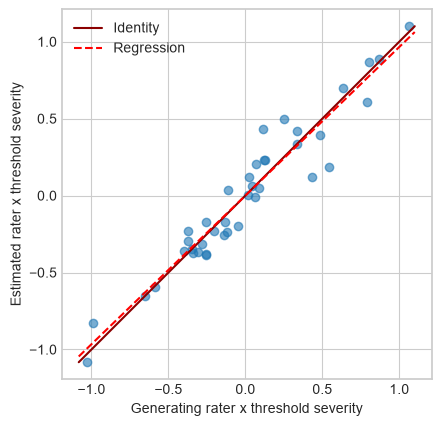

rater x threshold severity Pearson correlation:              0.96
rater x threshold severity SD ratio (estimated / generating): 1.006
rater x threshold severity regression coefficient:            0.966
rater x threshold severity RMSE:                              0.131


In [20]:
orig_severities = mfrm.generating.facet_effects.unstack()
est_severities = mfrm.raters_thresholds.unstack()
recovery_plot(orig_severities, est_severities, 'rater x threshold severity', 'my_mfrm_thresholds_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [21]:
%%time
mfrm.person_stats_df_thresholds(full=True)
mfrm.person_stats_thresholds.to_csv('mfrm_thresholds_person_stats.csv')

CPU times: user 14 ms, sys: 1.1 ms, total: 15.1 ms
Wall time: 15.1 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [22]:
mfrm.person_stats_thresholds.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,1.204,0.176,0.159,302,480,0.629,0.816,0.919,-1.051,-0.394
Person_2,-0.749,0.139,0.152,223,480,0.465,1.185,1.107,1.317,0.736
Person_3,-3.095,0.155,0.156,101,480,0.210,1.015,1.007,0.149,0.097
Person_4,-0.214,0.149,0.146,249,480,0.519,0.969,0.966,-0.161,-0.146
Person_5,0.664,0.169,0.165,284,480,0.592,0.952,0.960,-0.215,-0.158
Person_6,-0.531,0.143,0.141,234,480,0.488,0.975,0.930,-0.132,-0.402
Person_7,-0.386,0.145,0.160,241,480,0.502,1.217,1.411,1.451,2.290
Person_8,-0.845,0.138,0.144,218,480,0.454,1.090,1.112,0.684,0.781
Person_9,0.496,0.165,0.157,278,480,0.579,0.906,0.920,-0.501,-0.388
Person_10,-1.807,0.134,0.133,165,480,0.344,0.973,0.954,-0.169,-0.291


And the same recovery check for person locations, against `mfrm.generating.persons`:

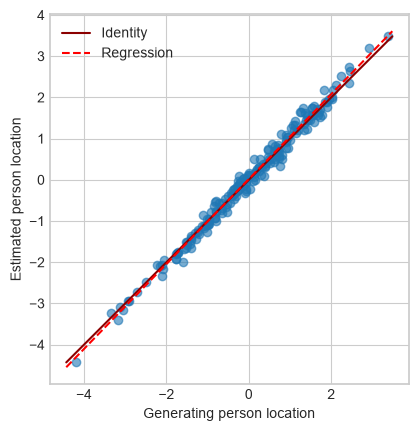

person location Pearson correlation:              0.994
person location SD ratio (estimated / generating): 1.037
person location regression coefficient:            1.03
person location RMSE:                              0.156


In [23]:
recovery_plot(mfrm.generating.persons, mfrm.persons_thresholds, 'person location', 'my_mfrm_thresholds_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [24]:
%%time
mfrm.test_stats_df_thresholds()
mfrm.test_stats_thresholds.to_csv('mfrm_thresholds_test_stats.csv')

CPU times: user 2.78 ms, sys: 712 μs, total: 3.5 ms
Wall time: 3.39 ms


Check the test statistics table

In [25]:
mfrm.test_stats_thresholds

,Items,Persons
Mean,-0.000,0.018
SD,0.772,1.380
Separation ratio,17.239,8.721
Strata,23.319,11.962
Reliability,0.997,0.987


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [26]:
%%time
mfrm.item_res_corr_analysis_thresholds()
mfrm.item_residual_correlations_thresholds.to_csv('mfrm_thresholds_item_residual_correlations.csv')
mfrm.item_loadings_thresholds.to_csv('mfrm_thresholds_item_loadings.csv')

CPU times: user 7.53 ms, sys: 2.38 ms, total: 9.91 ms
Wall time: 14.1 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [27]:
round(mfrm.item_residual_correlations_thresholds, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,0.017,-0.002,-0.026,-0.005,0.004,-0.026,0.005,-0.007,-0.020,-0.021,0.010
Item_2,0.017,1.000,0.003,-0.034,0.028,-0.046,0.003,-0.010,-0.005,-0.006,0.041,0.046
Item_3,-0.002,0.003,1.000,-0.016,0.011,0.003,-0.031,-0.031,-0.045,-0.004,0.003,0.010
Item_4,-0.026,-0.034,-0.016,1.000,-0.019,-0.065,-0.018,-0.039,-0.008,-0.034,-0.005,-0.014
Item_5,-0.005,0.028,0.011,-0.019,1.000,-0.054,-0.021,-0.034,-0.029,0.005,-0.015,0.002
Item_6,0.004,-0.046,0.003,-0.065,-0.054,1.000,0.029,-0.053,0.003,-0.001,0.010,-0.015
Item_7,-0.026,0.003,-0.031,-0.018,-0.021,0.029,1.000,-0.028,-0.020,-0.021,-0.018,-0.019
Item_8,0.005,-0.010,-0.031,-0.039,-0.034,-0.053,-0.028,1.000,-0.009,-0.013,-0.004,-0.025
Item_9,-0.007,-0.005,-0.045,-0.008,-0.029,0.003,-0.020,-0.009,1.000,-0.018,0.003,-0.024
Item_10,-0.020,-0.006,-0.004,-0.034,0.005,-0.001,-0.021,-0.013,-0.018,1.000,-0.027,-0.015


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [28]:
round(mfrm.item_loadings_thresholds['PC 1'], 3)

Item_1    -0.017
Item_2    -0.116
Item_3    -0.057
Item_4    -0.037
Item_5    -0.145
Item_6     0.204
Item_7     0.118
Item_8    -0.010
Item_9     0.094
Item_10    0.009
Item_11    0.020
Item_12   -0.096
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [29]:
%%time
mfrm.rater_res_corr_analysis_thresholds()
mfrm.rater_residual_correlations_thresholds.to_csv('mfrm_thresholds_rater_residual_correlations.csv')
mfrm.rater_loadings_thresholds.to_csv('mfrm_thresholds_rater_loadings.csv')

CPU times: user 12.5 ms, sys: 987 μs, total: 13.5 ms
Wall time: 13.6 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [30]:
round(mfrm.rater_residual_correlations_thresholds, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,0.009,-0.019,-0.011,-0.009,-0.007,-0.018,0.009
Rater_2,0.009,1.000,-0.002,0.012,-0.057,-0.034,-0.018,0.009
Rater_3,-0.019,-0.002,1.000,-0.015,-0.012,-0.023,-0.026,-0.049
Rater_4,-0.011,0.012,-0.015,1.000,-0.032,-0.015,-0.024,-0.002
Rater_5,-0.009,-0.057,-0.012,-0.032,1.000,-0.037,-0.006,-0.027
Rater_6,-0.007,-0.034,-0.023,-0.015,-0.037,1.000,-0.033,-0.001
Rater_7,-0.018,-0.018,-0.026,-0.024,-0.006,-0.033,1.000,-0.043
Rater_8,0.009,0.009,-0.049,-0.002,-0.027,-0.001,-0.043,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [31]:
round(mfrm.rater_loadings_thresholds['PC 1'], 3)

Rater_1    0.072
Rater_2    0.061
Rater_3   -0.151
Rater_4    0.057
Rater_5   -0.170
Rater_6    0.117
Rater_7   -0.196
Rater_8    0.230
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

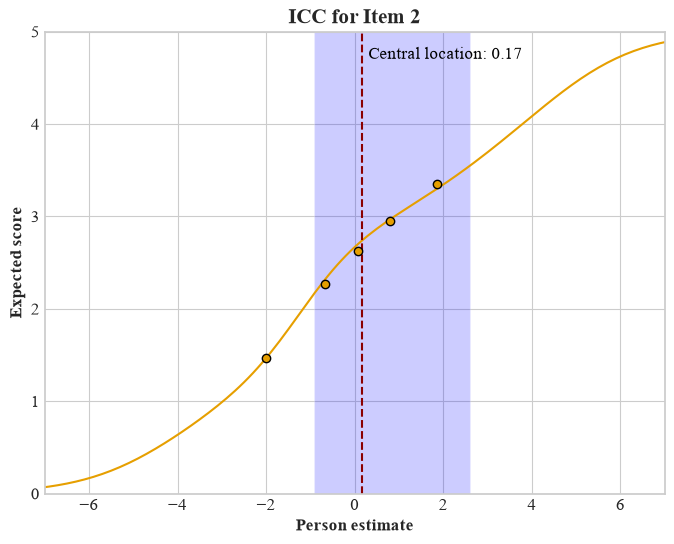

In [32]:
mfrm.icc_thresholds('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_thresholds_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

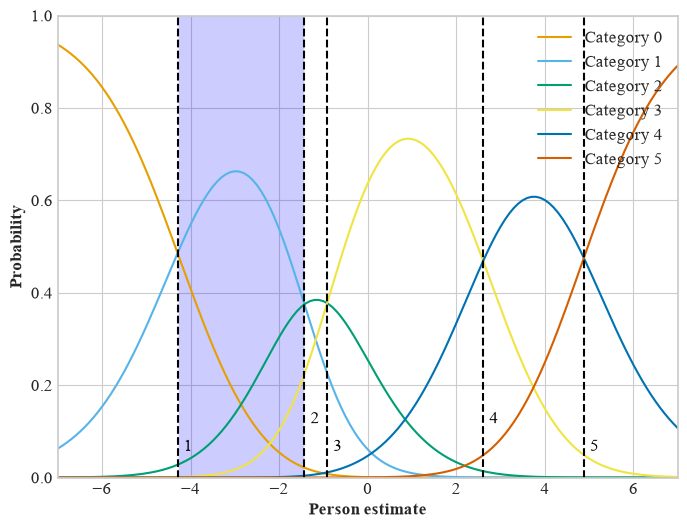

In [33]:
mfrm.crcs_thresholds('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_thresholds_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

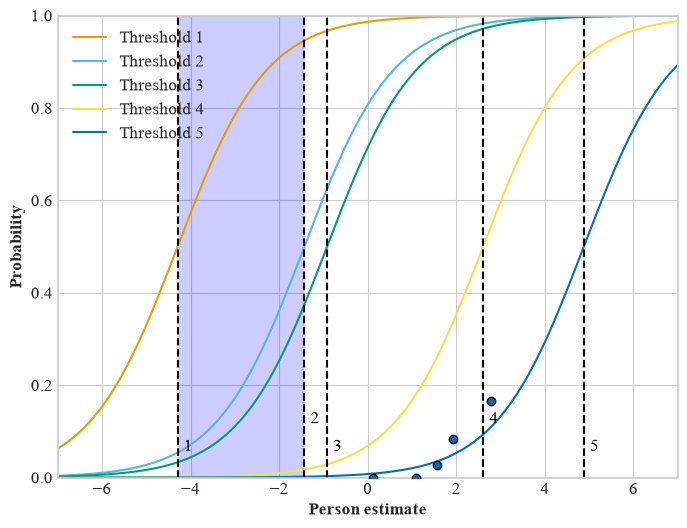

In [34]:
mfrm.threshold_ccs_thresholds('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_thresholds_threshold_ccs')

Produce an item information function curve for Item 2

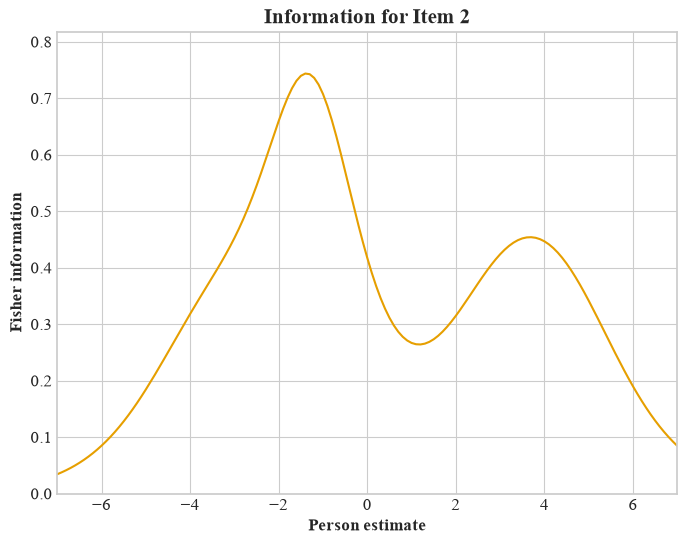

In [35]:
mfrm.iic_thresholds('Item_2', title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_thresholds_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

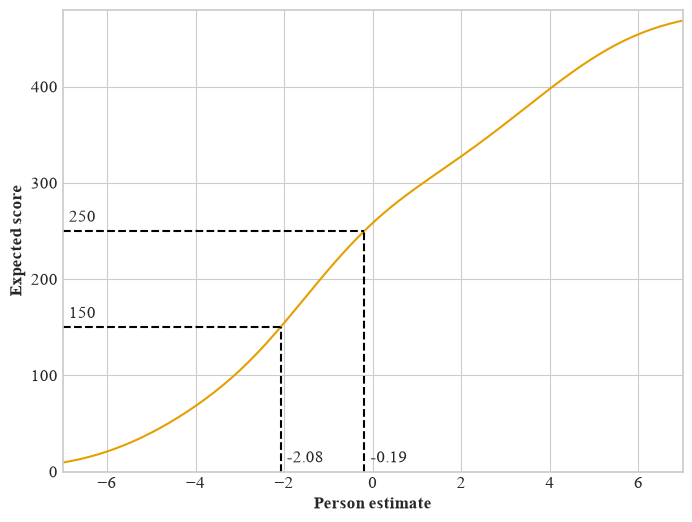

In [36]:
mfrm.tcc_thresholds(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_thresholds_tcc')

Produce a test information curve

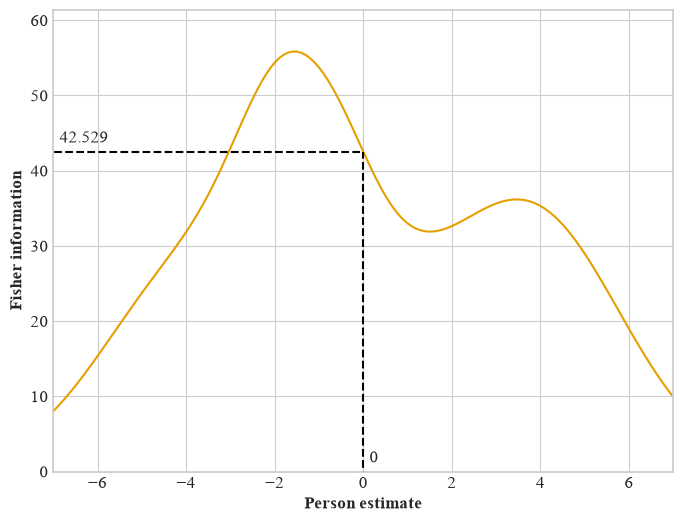

In [37]:
mfrm.test_info_thresholds(point_info_lines=[0], point_info_labels=True, xmin=-7, xmax=7, filename='my_mfrm_thresholds_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

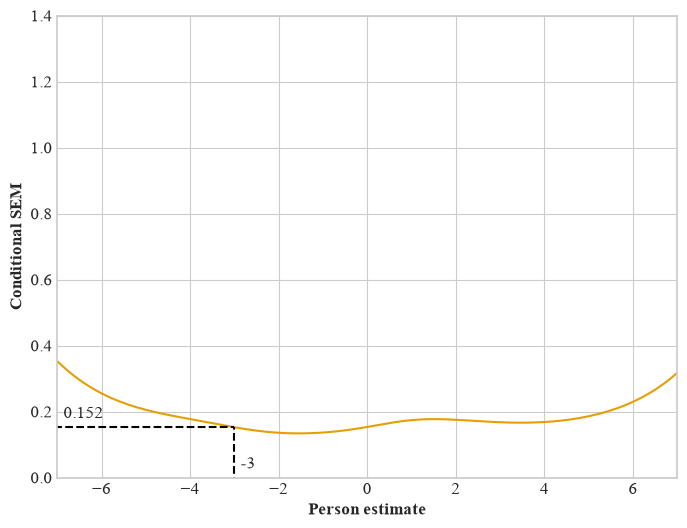

In [38]:
mfrm.test_csem_thresholds(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_thresholds_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

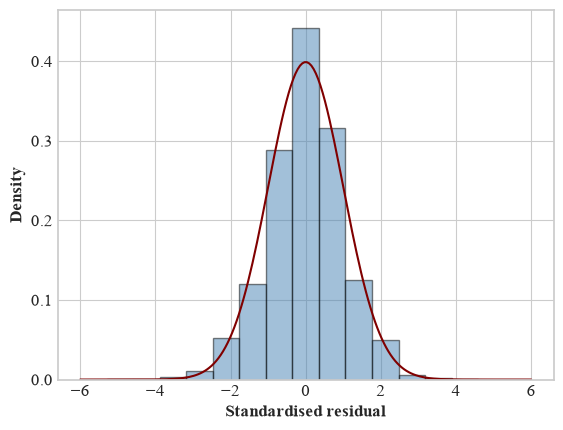

In [39]:
mfrm.std_residuals_plot_thresholds(bin_width=0.6, normal=True, filename='my_mfrm_thresholds_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [40]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_thresholds_anchor(anchors)

CPU times: user 1.16 ms, sys: 116 μs, total: 1.28 ms
Wall time: 1.18 ms


Check the anchored thresholds against the unanchored thresholds

In [41]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                           'Anchored': mfrm.anchor_thresholds_thresholds})
round(threshold_check, 3)

,Unanchored,Anchored
1,-4.462,-4.504
2,-1.599,-1.761
3,-1.086,-0.754
4,2.437,2.544
5,4.710,4.474


Check the anchored rater x threshold severities against the unanchored ones (two separate dataframes).

In [42]:
round(mfrm.raters_thresholds, 3)

,1,2,3,4,5
Rater_1,0.610,0.052,-0.170,0.232,-0.230
Rater_2,-0.382,-0.170,-0.227,-0.317,-0.011
Rater_3,0.233,-0.364,1.100,-0.389,-0.651
Rater_4,-0.831,-0.371,0.422,0.697,-0.259
Rater_5,0.183,-0.196,-0.594,0.335,0.203
Rater_6,0.038,0.123,-0.238,-1.083,0.393
Rater_7,0.499,0.060,0.002,0.884,0.435
Rater_8,-0.349,0.865,-0.295,-0.360,0.120


In [43]:
round(mfrm.anchor_raters_thresholds, 3)

,1,2,3,4,5
Rater_1,0.703,0.265,-0.451,0.177,0.058
Rater_2,-0.290,0.043,-0.509,-0.373,0.277
Rater_3,0.326,-0.151,0.819,-0.445,-0.363
Rater_4,-0.739,-0.158,0.141,0.641,0.029
Rater_5,0.275,0.018,-0.875,0.280,0.491
Rater_6,0.130,0.337,-0.519,-1.139,0.681
Rater_7,0.592,0.273,-0.280,0.829,0.723
Rater_8,-0.257,1.078,-0.576,-0.416,0.407


Produce a Wright map (unanchored), showing the person location distribution alongside an item strip (one row per item, divided into its own category segments at each Rasch-Andrich threshold) and a rater panel, with mean/±1SD/±2SD reference marks for persons

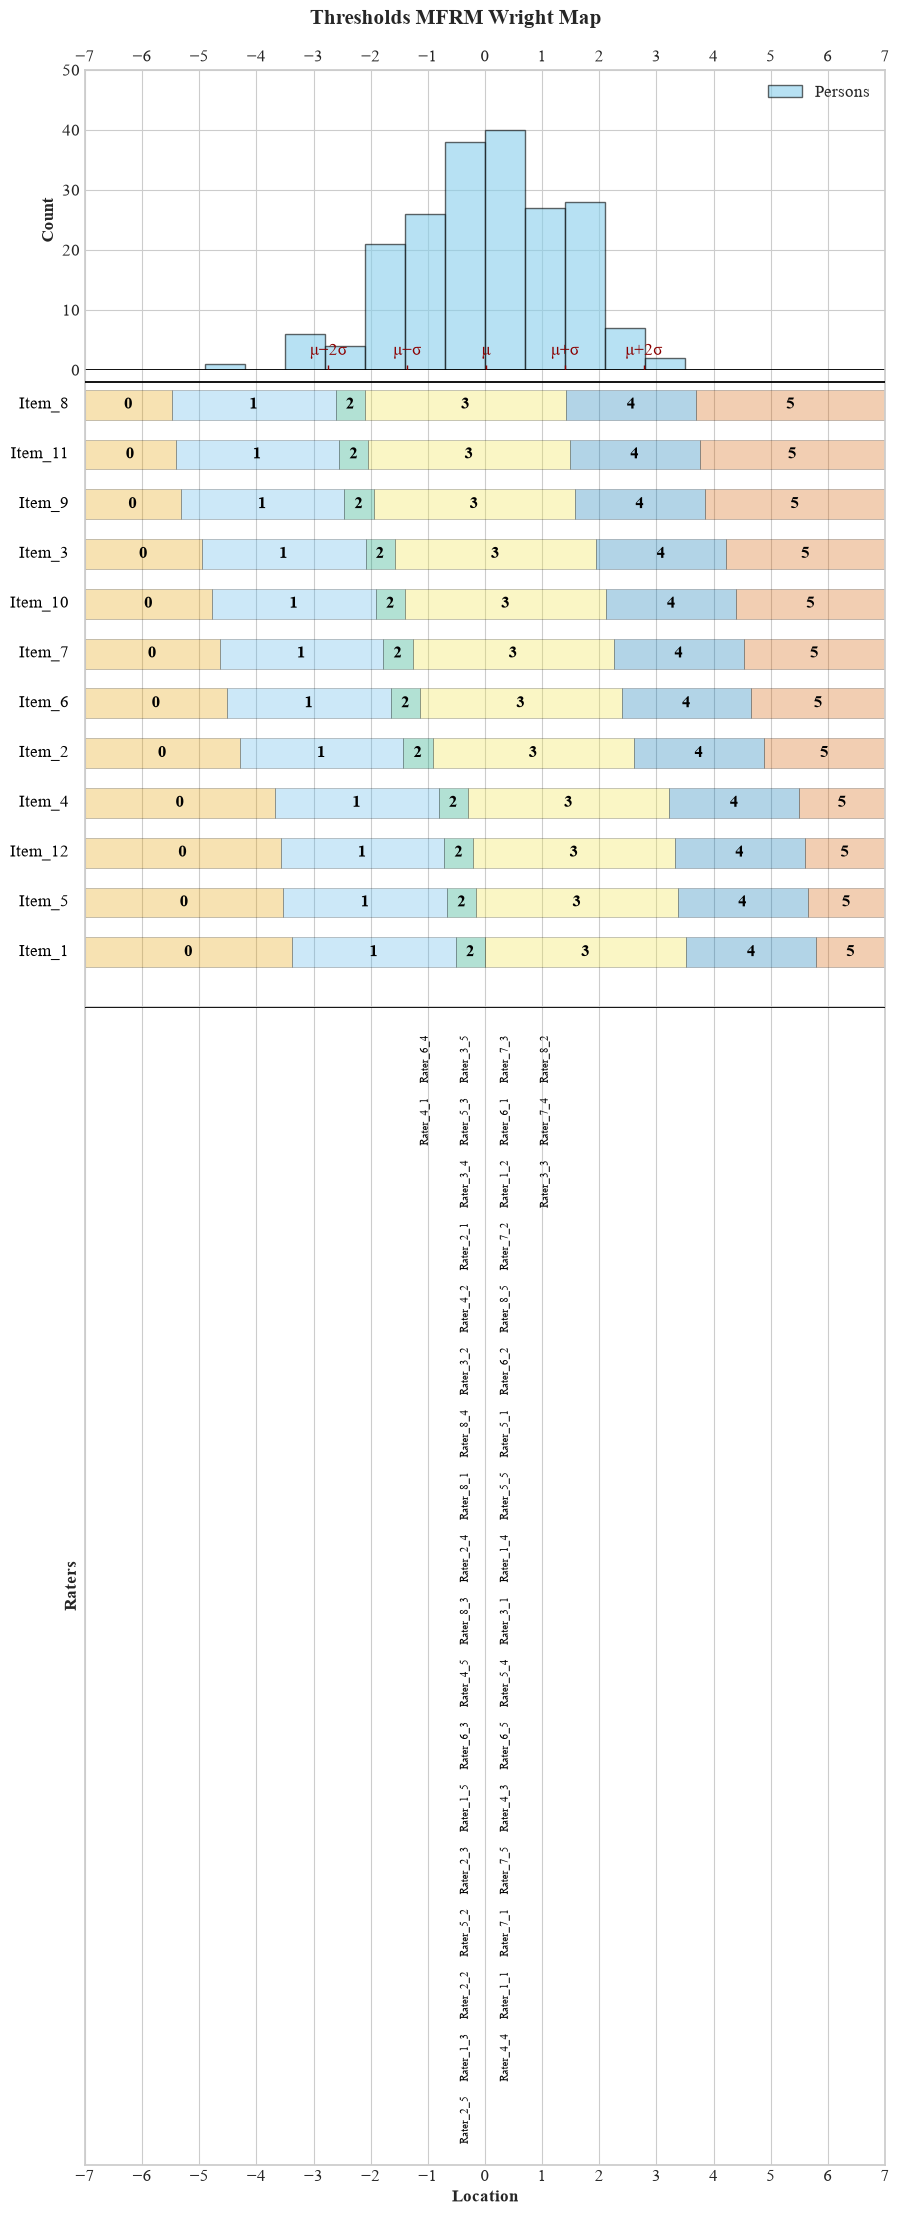

In [44]:
mfrm.wright_map_thresholds(item_strip=True, facet_labels=True, distribution_markers=True, title='Thresholds MFRM Wright Map', filename='my_mfrm_thresholds_wright_map')